In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [4]:
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.86MB/s]


In [5]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)


In [6]:
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1000, shuffle=False)


In [7]:
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # Output: 32x28x28
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # Output: 64x14x14
        self.pool = nn.MaxPool2d(2, 2)  # Downsamples by 2 (28x28 → 14x14 → 7x7)

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

        # Other layers
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        # Convolutional + ReLU + Pooling
        x = self.pool(F.relu(self.conv1(x)))  # Output: 32x14x14
        x = self.pool(F.relu(self.conv2(x)))  # Output: 64x7x7

        # Flatten
        x = x.view(-1, 64 * 7 * 7)  # Flatten to [batch_size, features]

        # Fully connected layers + ReLU + Dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)



In [9]:
for epoch in range(5):
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}")

Epoch 1, Loss: 0.1582
Epoch 2, Loss: 0.0525
Epoch 3, Loss: 0.0392
Epoch 4, Loss: 0.0315
Epoch 5, Loss: 0.0241


In [10]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 99.12%


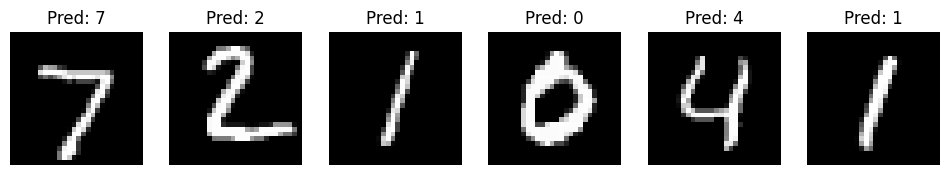

In [11]:
images, labels = next(iter(testloader))
images = images.to(device)
outputs = model(images)
_, preds = torch.max(outputs, 1)
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for idx in range(6):
    ax = axes[idx]
    ax.imshow(images[idx].cpu().squeeze(), cmap='gray')
    ax.set_title(f"Pred: {preds[idx].item()}")
    ax.axis('off')
plt.show()
